In [ ]:
import os
import shutil
import pandas as pd
import numpy as np
os.system('pip install -q kagglehub')
import kagglehub
print("Libraries imported.")

Libraries imported.


Download Dataset

In [23]:
print("Downloading dataset...")
try:
    cache_path = kagglehub.dataset_download("usdot/flight-delays")
    print(f"Downloaded to: {cache_path}")
except Exception as e:
    print(f"Download failed: {e}")
    raise

Downloaded to: C:\Users\Asus\.cache\kagglehub\datasets\usdot\flight-delays\versions\1


Move downloaded files to Local Directory

In [24]:
local_dir = "./flight_delays_data"
print(f"Moving dataset to {local_dir}...")

if os.path.exists(local_dir):
    shutil.rmtree(local_dir)
shutil.copytree(cache_path, local_dir)

print("Dataset moved successfully.")

Moving dataset to ./flight_delays_data...
Dataset moved successfully.


Load Flights Data

In [25]:
flights_path = os.path.join(local_dir, "flights.csv")
print("Loading flights.csv...")
dtype_spec_flights = {
    'AIRLINE': str,
    'ORIGIN_AIRPORT': str,
    'DESTINATION_AIRPORT': str,
    'TAIL_NUMBER': str,
    'CANCELLATION_REASON': str
}
flights = pd.read_csv(flights_path, dtype=dtype_spec_flights, low_memory=False)
print(f"Loaded flights.csv. Total records: {len(flights)}")
print(flights.head(5))

Loading flights.csv...
Loaded flights.csv. Total records: 5819079
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  ARRIVAL_TIME  \
0            ANC                 SEA                    5  ...         408.0   
1            LAX                 PBI                   10  ...         741.0   
2            SFO                 CLT                   20  ...         811.0   
3            LAX                 MIA                   20  ...         756.0   
4            SEA                 ANC                   25  ...         259.0   

   ARRIVAL_DELAY  DIVERTED

Load Airlines Data (airlines.csv)

In [ ]:
airlines_path = os.path.join(local_dir, "airlines.csv")
print("Loading airlines.csv...")

airlines = pd.read_csv(airlines_path, dtype={'IATA_CODE': str})
print(f"Loaded airlines.csv. Total records: {len(airlines)}")
print(airlines.head(5))

Loading airlines.csv...
Loaded airlines.csv. Total records: 14
  IATA_CODE                 AIRLINE
0        UA   United Air Lines Inc.
1        AA  American Airlines Inc.
2        US         US Airways Inc.
3        F9  Frontier Airlines Inc.
4        B6         JetBlue Airways


Load Airports Data (airports.csv)


In [ ]:
airports_path = os.path.join(local_dir, "airports.csv")
print("Loading airports.csv...")

airports = pd.read_csv(airports_path, dtype={'IATA_CODE': str})
print(f"Loaded airports.csv. Total records: {len(airports)}")
print(airports.head(5))

Loading airports.csv...
Loaded airports.csv. Total records: 322
  IATA_CODE                              AIRPORT         CITY STATE COUNTRY  \
0       ABE  Lehigh Valley International Airport    Allentown    PA     USA   
1       ABI             Abilene Regional Airport      Abilene    TX     USA   
2       ABQ    Albuquerque International Sunport  Albuquerque    NM     USA   
3       ABR            Aberdeen Regional Airport     Aberdeen    SD     USA   
4       ABY   Southwest Georgia Regional Airport       Albany    GA     USA   

   LATITUDE  LONGITUDE  
0  40.65236  -75.44040  
1  32.41132  -99.68190  
2  35.04022 -106.60919  
3  45.44906  -98.42183  
4  31.53552  -84.19447  


fill missing values in all delay-related columns with `0`.

In [28]:
delay_cols = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

print("Filling missing delays with 0...")
for col in delay_cols:
    if col in flights.columns:
        flights[col] = flights[col].fillna(0)
print(f"Delays cleaned. Processed records: {len(flights)}")
print(flights[delay_cols].head(5))

Filling missing delays with 0...
Delays cleaned. Processed records: 5819079
   DEPARTURE_DELAY  ARRIVAL_DELAY  AIR_SYSTEM_DELAY  SECURITY_DELAY  \
0            -11.0          -22.0               0.0             0.0   
1             -8.0           -9.0               0.0             0.0   
2             -2.0            5.0               0.0             0.0   
3             -5.0           -9.0               0.0             0.0   
4             -1.0          -21.0               0.0             0.0   

   AIRLINE_DELAY  LATE_AIRCRAFT_DELAY  WEATHER_DELAY  
0            0.0                  0.0            0.0  
1            0.0                  0.0            0.0  
2            0.0                  0.0            0.0  
3            0.0                  0.0            0.0  
4            0.0                  0.0            0.0  


Clean Cancellations

In [29]:
print("Cleaning cancellation data...")
flights['CANCELLED'] = flights['CANCELLED'].fillna(0).astype(int)

if 'CANCELLATION_REASON' in flights.columns:
    flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].fillna('None')
print(f"Cancellations cleaned. Processed records: {len(flights)}")
print(flights[['CANCELLED', 'CANCELLATION_REASON']].head(5))

Cleaning cancellation data...
Cancellations cleaned. Processed records: 5819079
   CANCELLED CANCELLATION_REASON
0          0                None
1          0                None
2          0                None
3          0                None
4          0                None


Combining the `YEAR`, `MONTH`, and `DAY` columns into a single datetime object `FL_DATE`.

In [30]:
print("Creating FL_DATE...")
flights['FL_DATE'] = pd.to_datetime(
    flights[['YEAR', 'MONTH', 'DAY']], 
    errors='coerce'
)
print(f"FL_DATE created. Processed records: {len(flights)}")
print(flights[['YEAR', 'MONTH', 'DAY', 'FL_DATE']].head(5))

Creating FL_DATE...
FL_DATE created. Processed records: 5819079
   YEAR  MONTH  DAY    FL_DATE
0  2015      1    1 2015-01-01
1  2015      1    1 2015-01-01
2  2015      1    1 2015-01-01
3  2015      1    1 2015-01-01
4  2015      1    1 2015-01-01


In [31]:
print("Extracting Departure Hour...")
# Ensure numeric and fill metadata
flights['SCHEDULED_DEPARTURE'] = pd.to_numeric(flights['SCHEDULED_DEPARTURE'], errors='coerce').fillna(0).astype(int)

# Extract hour (HHMM // 100), handle 2400 via modulo 24
flights['DEP_HOUR'] = (flights['SCHEDULED_DEPARTURE'] // 100) % 24
print(f"DEP_HOUR extracted. Processed records: {len(flights)}")
print(flights[['SCHEDULED_DEPARTURE', 'DEP_HOUR']].head(5))

Extracting Departure Hour...
DEP_HOUR extracted. Processed records: 5819079
   SCHEDULED_DEPARTURE  DEP_HOUR
0                    5         0
1                   10         0
2                   20         0
3                   20         0
4                   25         0


Cleaning `SCHEDULED_ARRIVAL` and extract the hour (0-23).

In [32]:
print("Extracting Arrival Hour...")
flights['SCHEDULED_ARRIVAL'] = pd.to_numeric(flights['SCHEDULED_ARRIVAL'], errors='coerce').fillna(0).astype(int)
flights['ARR_HOUR'] = (flights['SCHEDULED_ARRIVAL'] // 100) % 24
print(f"ARR_HOUR extracted. Processed records: {len(flights)}")
print(flights[['SCHEDULED_ARRIVAL', 'ARR_HOUR']].head(5))

Extracting Arrival Hour...
ARR_HOUR extracted. Processed records: 5819079
   SCHEDULED_ARRIVAL  ARR_HOUR
0                430         4
1                750         7
2                806         8
3                805         8
4                320         3


Combining ORIGIN_AIRPORT and DESTINATION_AIRPORT to create a ROUTE identifier.

In [33]:
print("Creating ROUTE feature...")
# Fill NaNs to avoid string errors
flights['ORIGIN_AIRPORT'] = flights['ORIGIN_AIRPORT'].fillna('UNKNOWN')
flights['DESTINATION_AIRPORT'] = flights['DESTINATION_AIRPORT'].fillna('UNKNOWN')

flights['ROUTE'] = flights['ORIGIN_AIRPORT'] + '-' + flights['DESTINATION_AIRPORT']
print(f"ROUTE column created. Processed records: {len(flights)}")
print(flights[['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']].head(5))

Creating ROUTE feature...
ROUTE column created. Processed records: 5819079
  ORIGIN_AIRPORT DESTINATION_AIRPORT    ROUTE
0            ANC                 SEA  ANC-SEA
1            LAX                 PBI  LAX-PBI
2            SFO                 CLT  SFO-CLT
3            LAX                 MIA  LAX-MIA
4            SEA                 ANC  SEA-ANC


A binary column ON_TIME which is 1 if the flight arrived early or on time, and 0 otherwise

In [ ]:
print("Creating ON_TIME indicator...")
flights['ON_TIME'] = (flights['ARRIVAL_DELAY'] <= 0).astype(int)
print(f"ON_TIME created. Processed records: {len(flights)}")
print(flights[['ARRIVAL_DELAY', 'ON_TIME']].head(5))

Creating ON_TIME indicator...
ON_TIME created. Processed records: 5819079
   ARRIVAL_DELAY  ON_TIME
0          -22.0        1
1           -9.0        1
2            5.0        0
3           -9.0        1
4          -21.0        1


joining the airlines dataframe to add the full AIRLINE_NAME

In [35]:
print("Merging Airline names...")
flights = flights.merge(
    airlines[['IATA_CODE', 'AIRLINE']],
    left_on='AIRLINE',
    right_on='IATA_CODE',
    how='left'
)
flights.rename(columns={'AIRLINE_y': 'AIRLINE_NAME'}, inplace=True)
if 'AIRLINE_x' in flights.columns: 
    flights.rename(columns={'AIRLINE_x': 'AIRLINE_CODE'}, inplace=True)
flights.drop(columns=['IATA_CODE'], inplace=True, errors='ignore')
print(f"Airline names merged. Processed records: {len(flights)}")
print(flights[['AIRLINE_CODE', 'AIRLINE_NAME']].head(5))

Merging Airline names...
Airline names merged. Processed records: 5819079
  AIRLINE_CODE            AIRLINE_NAME
0           AS    Alaska Airlines Inc.
1           AA  American Airlines Inc.
2           US         US Airways Inc.
3           AA  American Airlines Inc.
4           AS    Alaska Airlines Inc.


joining the airports dataframe to add the full ORIGIN_AIRPORT_NAME.

In [36]:
print("Merging Airport names...")
flights = flights.merge(
    airports[['IATA_CODE', 'AIRPORT']],
    left_on='ORIGIN_AIRPORT',
    right_on='IATA_CODE',
    how='left'
)
flights.rename(columns={'AIRPORT': 'ORIGIN_AIRPORT_NAME'}, inplace=True)
flights.drop(columns=['IATA_CODE'], inplace=True, errors='ignore')
print(f"Airport names merged. Processed records: {len(flights)}")
print(flights[['ORIGIN_AIRPORT', 'ORIGIN_AIRPORT_NAME']].head(5))

Merging Airport names...
Airport names merged. Processed records: 5819079
  ORIGIN_AIRPORT                          ORIGIN_AIRPORT_NAME
0            ANC  Ted Stevens Anchorage International Airport
1            LAX            Los Angeles International Airport
2            SFO          San Francisco International Airport
3            LAX            Los Angeles International Airport
4            SEA         Seattle-Tacoma International Airport


reducing dataset memory footprint.

In [ ]:
print("Optimizing memory...")
# Downcast floats
for col in flights.select_dtypes(include=['float64']).columns:
    flights[col] = pd.to_numeric(flights[col], downcast='float')

# Downcast integers
for col in flights.select_dtypes(include=['int64']).columns:
    flights[col] = pd.to_numeric(flights[col], downcast='integer')

print(f"Memory optimized. Processed records: {len(flights)}")
print(flights.info())

Optimizing memory...
Memory optimized. Processed records: 5819079
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 38 columns):
 #   Column               Dtype         
---  ------               -----         
 0   YEAR                 int16         
 1   MONTH                int8          
 2   DAY                  int8          
 3   DAY_OF_WEEK          int8          
 4   AIRLINE_CODE         category      
 5   FLIGHT_NUMBER        int16         
 6   TAIL_NUMBER          category      
 7   ORIGIN_AIRPORT       category      
 8   DESTINATION_AIRPORT  category      
 9   SCHEDULED_DEPARTURE  int16         
 10  DEPARTURE_TIME       float32       
 11  DEPARTURE_DELAY      float32       
 12  TAXI_OUT             float32       
 13  WHEELS_OFF           float32       
 14  SCHEDULED_TIME       float32       
 15  ELAPSED_TIME         float32       
 16  AIR_TIME             float32       
 17  DISTANCE             int16         
 

saving the processed dataset to cleaned_flights.csv.

In [38]:
output_file = "cleaned_flights.csv"
print(f"Saving to {output_file}...")

flights.to_csv(output_file, index=False)
print(f"Pipeline complete: File saved. Final record count: {len(flights)}")
print(flights.head(5))

Saving to cleaned_flights.csv...
Pipeline complete: File saved. Final record count: 5819079
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE_CODE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4           AS             98      N407AS   
1  2015      1    1            4           AA           2336      N3KUAA   
2  2015      1    1            4           US            840      N171US   
3  2015      1    1            4           AA            258      N3HYAA   
4  2015      1    1            4           AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  AIRLINE_DELAY  \
0            ANC                 SEA                    5  ...            0.0   
1            LAX                 PBI                   10  ...            0.0   
2            SFO                 CLT                   20  ...            0.0   
3            LAX                 MIA                   20  ...            0.0   
4            SEA                 ANC          

Milestone-2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading cleaned dataset...")
df = pd.read_csv("cleaned_flights.csv")

print("Dataset loaded:", df.shape)
df.head()

Loading cleaned dataset...


C:\Users\Asus\AppData\Local\Temp\ipykernel_16936\1056195463.py:6: DtypeWarning: Columns (7,8,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_flights.csv")


Dataset loaded: (5819079, 38)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FL_DATE,DEP_HOUR,ARR_HOUR,ROUTE,ON_TIME,AIRLINE_NAME,ORIGIN_AIRPORT_NAME
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0.0,0.0,0.0,2015-01-01,0,4,ANC-SEA,1,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0.0,0.0,0.0,2015-01-01,0,7,LAX-PBI,1,American Airlines Inc.,Los Angeles International Airport
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0.0,0.0,0.0,2015-01-01,0,8,SFO-CLT,0,US Airways Inc.,San Francisco International Airport
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0.0,0.0,0.0,2015-01-01,0,8,LAX-MIA,1,American Airlines Inc.,Los Angeles International Airport
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0.0,0.0,0.0,2015-01-01,0,3,SEA-ANC,1,Alaska Airlines Inc.,Seattle-Tacoma International Airport


In [2]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Visualization settings applied.")

Visualization settings applied.


Plotting top airlines...


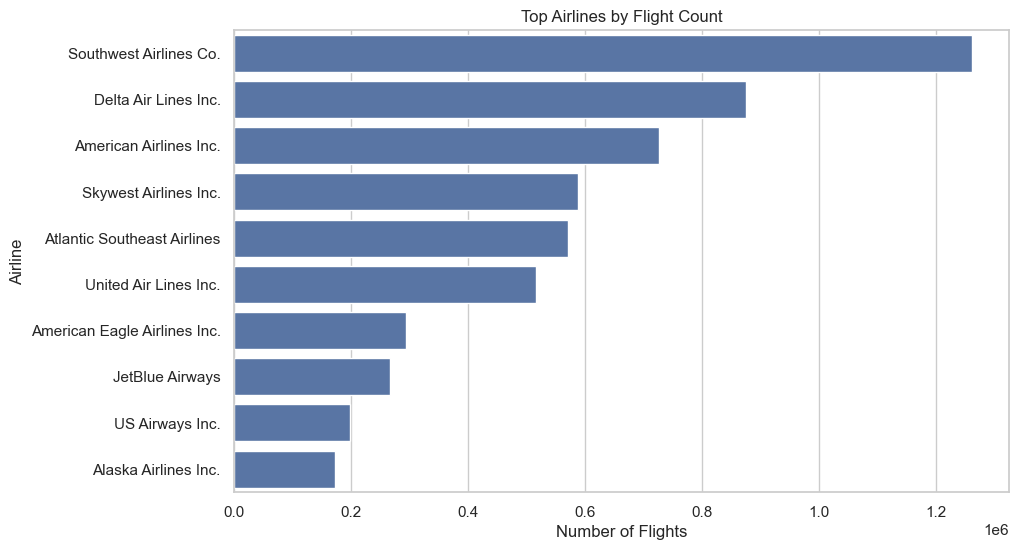

In [3]:
print("Plotting top airlines...")

top_airlines = df['AIRLINE_NAME'].value_counts().head(10)

sns.barplot(x=top_airlines.values, y=top_airlines.index)

plt.title("Top Airlines by Flight Count")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")
plt.show()

Plotting top routes...


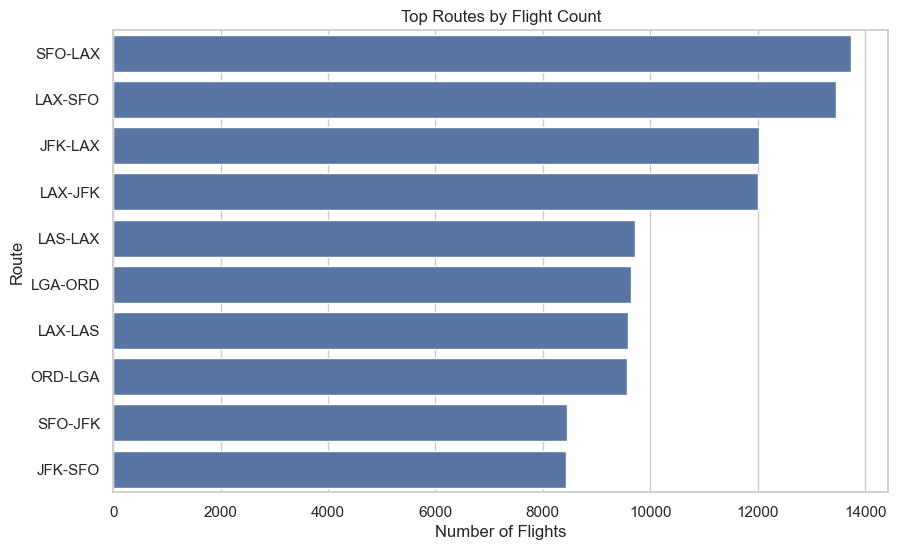

In [4]:
print("Plotting top routes...")

top_routes = df['ROUTE'].value_counts().head(10)

sns.barplot(x=top_routes.values, y=top_routes.index)

plt.title("Top Routes by Flight Count")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

Plotting flights by month...


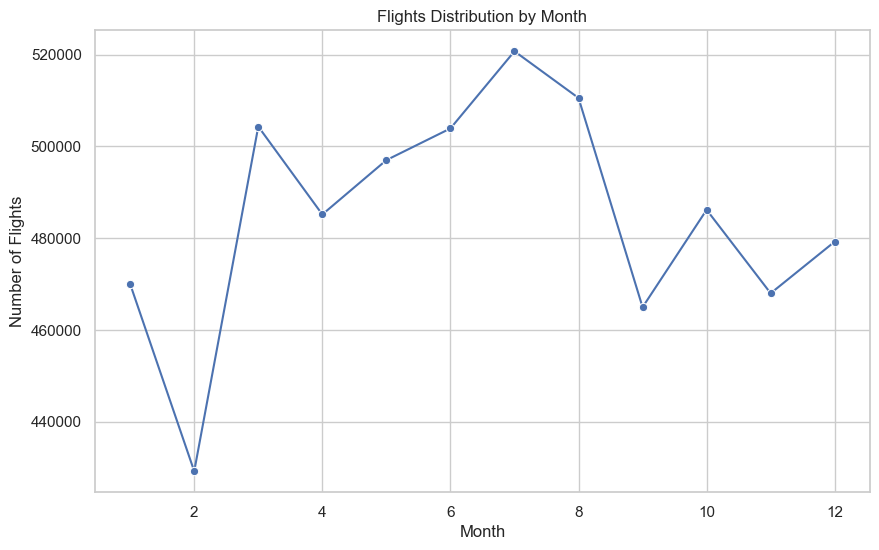

In [5]:
print("Plotting flights by month...")

month_counts = df['MONTH'].value_counts().sort_index()

sns.lineplot(x=month_counts.index, y=month_counts.values, marker="o")

plt.title("Flights Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

Plotting flights by day of week...


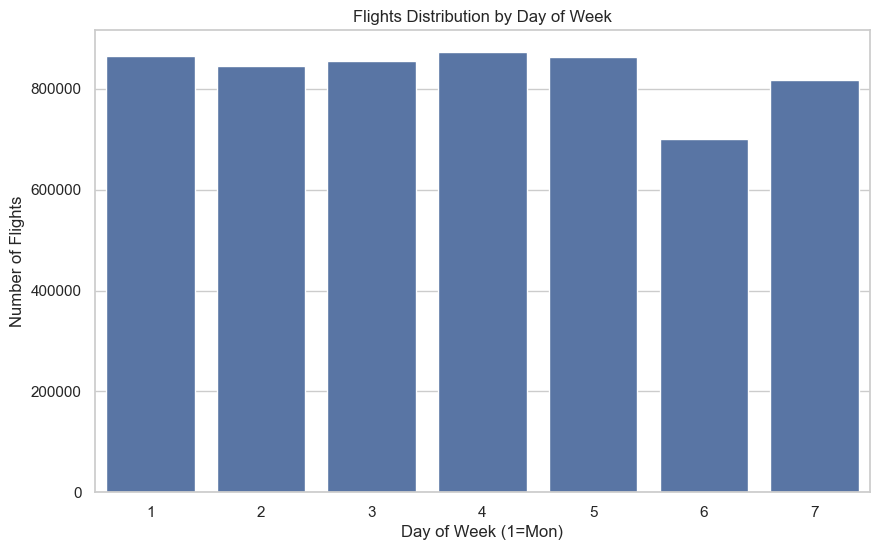

In [6]:
print("Plotting flights by day of week...")

day_counts = df['DAY_OF_WEEK'].value_counts().sort_index()

sns.barplot(x=day_counts.index, y=day_counts.values)

plt.title("Flights Distribution by Day of Week")
plt.xlabel("Day of Week (1=Mon)")
plt.ylabel("Number of Flights")
plt.show()

Plotting flights by departure hour...


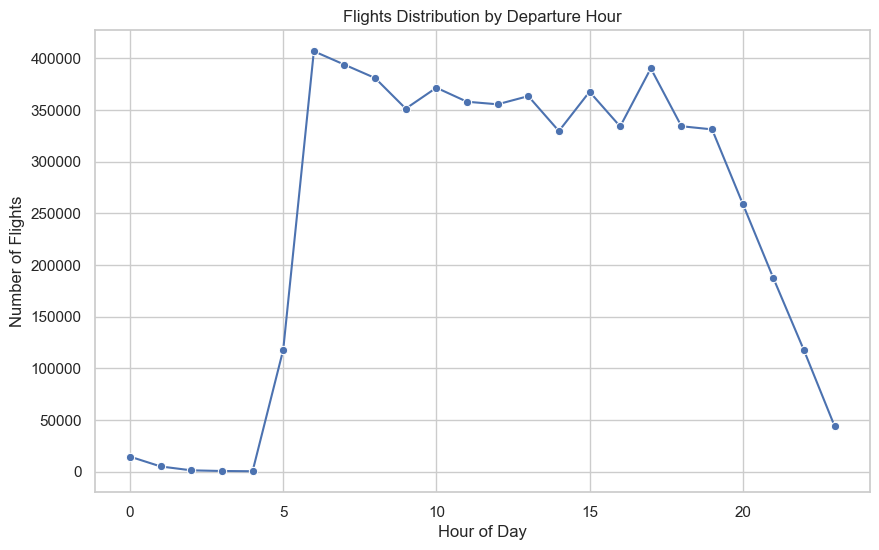

In [7]:
print("Plotting flights by departure hour...")

hour_counts = df['DEP_HOUR'].value_counts().sort_index()

sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker="o")

plt.title("Flights Distribution by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.show()

Plotting average delay by airline...


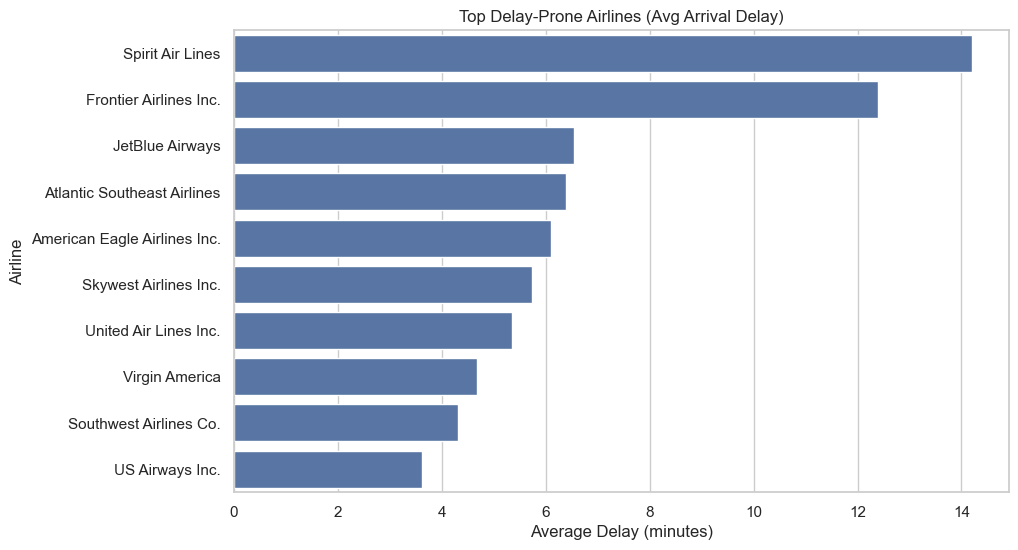

In [8]:
print("Plotting average delay by airline...")

delay_by_airline = (
    df.groupby('AIRLINE_NAME')['ARRIVAL_DELAY']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(x=delay_by_airline.values, y=delay_by_airline.index)

plt.title("Top Delay-Prone Airlines (Avg Arrival Delay)")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Airline")
plt.show()

Plotting delay causes...


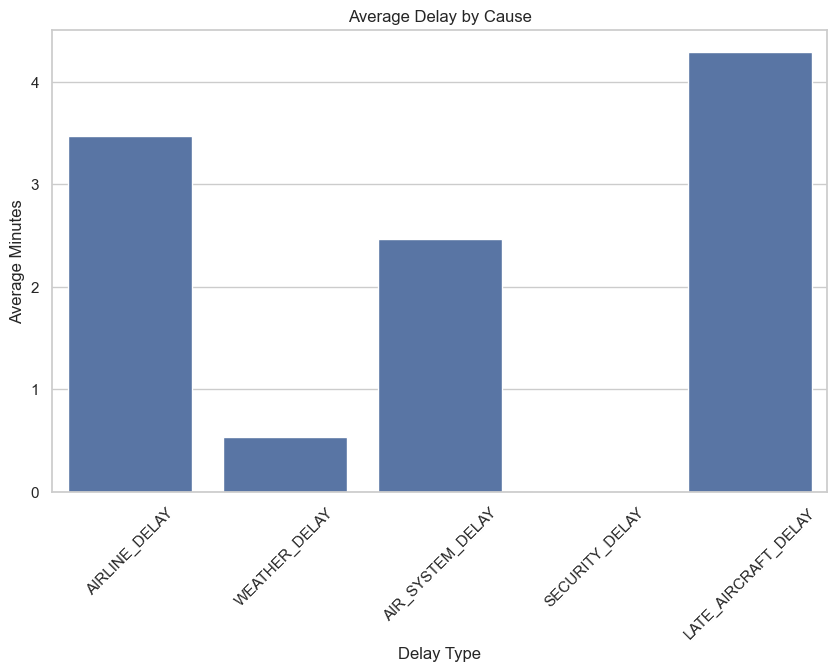

In [9]:
print("Plotting delay causes...")

delay_causes = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

avg_delays = df[delay_causes].mean()

sns.barplot(x=avg_delays.index, y=avg_delays.values)

plt.title("Average Delay by Cause")
plt.xlabel("Delay Type")
plt.ylabel("Average Minutes")
plt.xticks(rotation=45)
plt.show()

Plotting delay by hour...


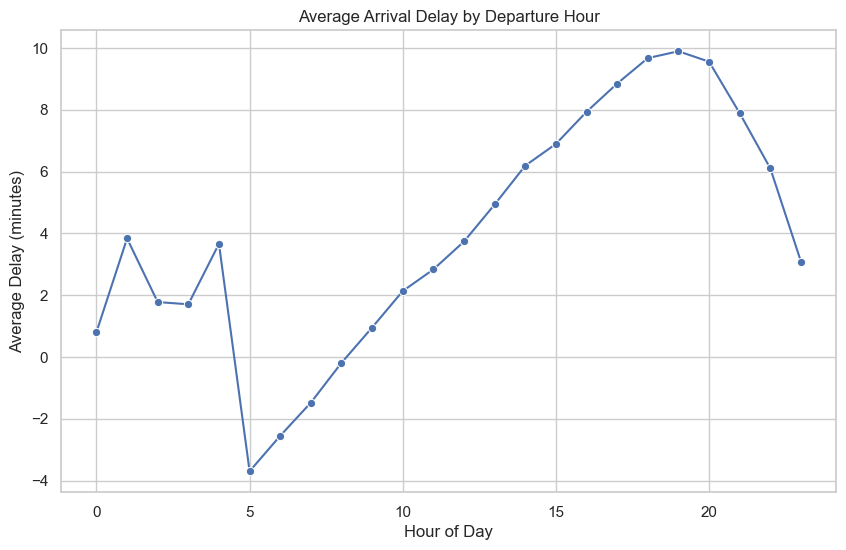

In [10]:
print("Plotting delay by hour...")

delay_by_hour = df.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean()

sns.lineplot(x=delay_by_hour.index, y=delay_by_hour.values, marker="o")

plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (minutes)")
plt.show()

MIlESTONE
3


C:\Users\Asus\AppData\Local\Temp\ipykernel_24484\2463931484.py:5: DtypeWarning: Columns (7,8,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_flights.csv")
C:\Users\Asus\AppData\Local\Temp\ipykernel_24484\2463931484.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_routes, x='FLIGHT_COUNT', y='ROUTE', palette='Blues_r')


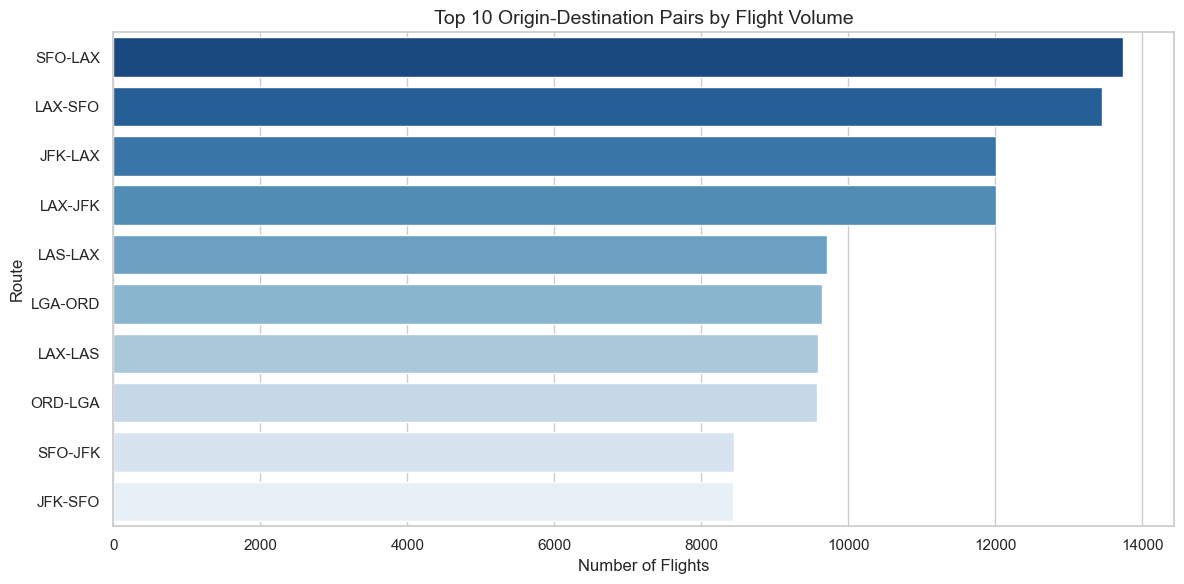

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_flights.csv")
sns.set(style="whitegrid")

# Top 10 Origin-Destination pairs
top_routes = df['ROUTE'].value_counts().head(10).reset_index()
top_routes.columns = ['ROUTE', 'FLIGHT_COUNT']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_routes, x='FLIGHT_COUNT', y='ROUTE', palette='Blues_r')
plt.title("Top 10 Origin-Destination Pairs by Flight Volume", fontsize=14)
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig("plot_0.png", dpi=150)
plt.show()

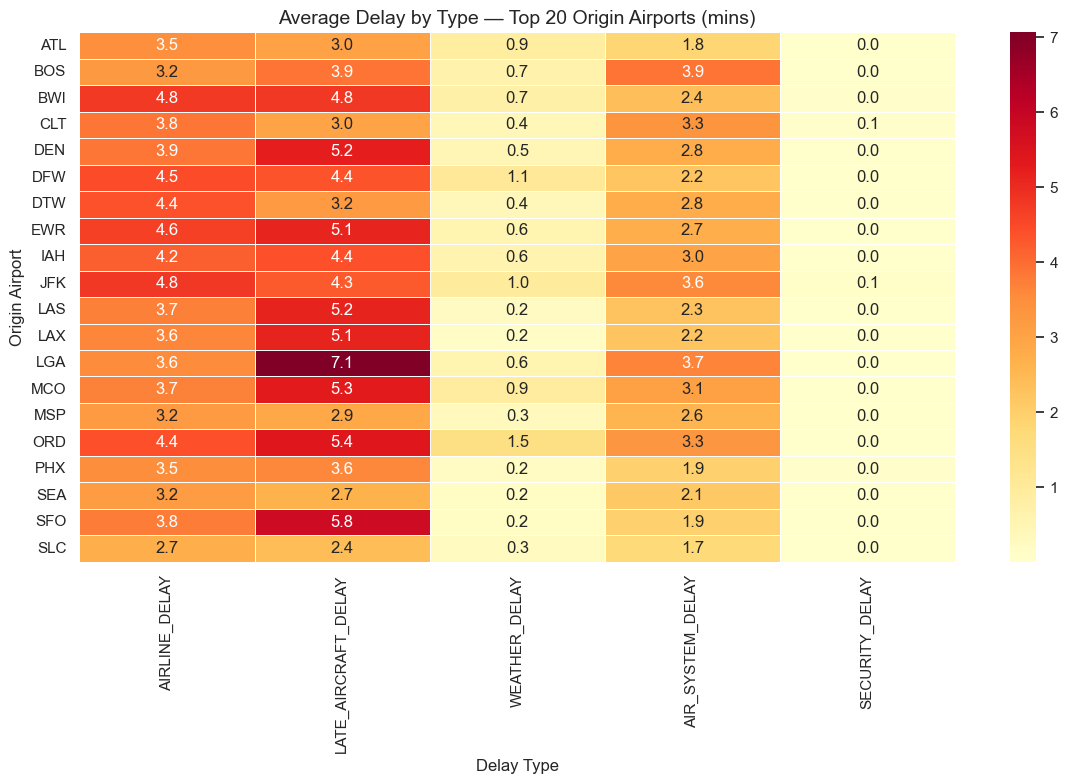

In [2]:
delay_types = ['AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 
               'AIR_SYSTEM_DELAY', 'SECURITY_DELAY']

# Top 20 busiest origin airports
top_origins = df['ORIGIN_AIRPORT'].value_counts().head(20).index

heatmap_data = (
    df[df['ORIGIN_AIRPORT'].isin(top_origins)]
    .groupby('ORIGIN_AIRPORT')[delay_types]
    .mean()
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Average Delay by Type — Top 20 Origin Airports (mins)", fontsize=14)
plt.xlabel("Delay Type")
plt.ylabel("Origin Airport")
plt.tight_layout()
plt.savefig("plot_1.png", dpi=150)
plt.show()

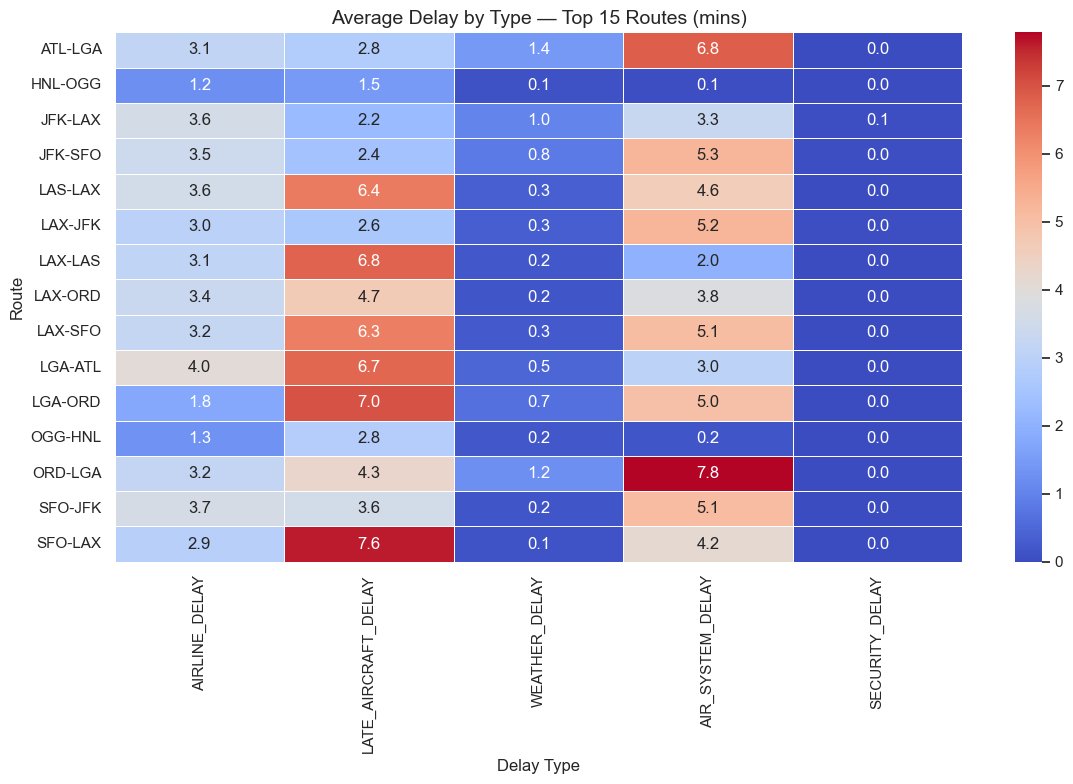

In [3]:
top_route_list = df['ROUTE'].value_counts().head(15).index

route_heatmap = (
    df[df['ROUTE'].isin(top_route_list)]
    .groupby('ROUTE')[delay_types]
    .mean()
)

plt.figure(figsize=(12, 8))
sns.heatmap(route_heatmap, annot=True, fmt=".1f", cmap="coolwarm", linewidths=0.5)
plt.title("Average Delay by Type — Top 15 Routes (mins)", fontsize=14)
plt.xlabel("Delay Type")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig("plot_2.png", dpi=150)
plt.show()

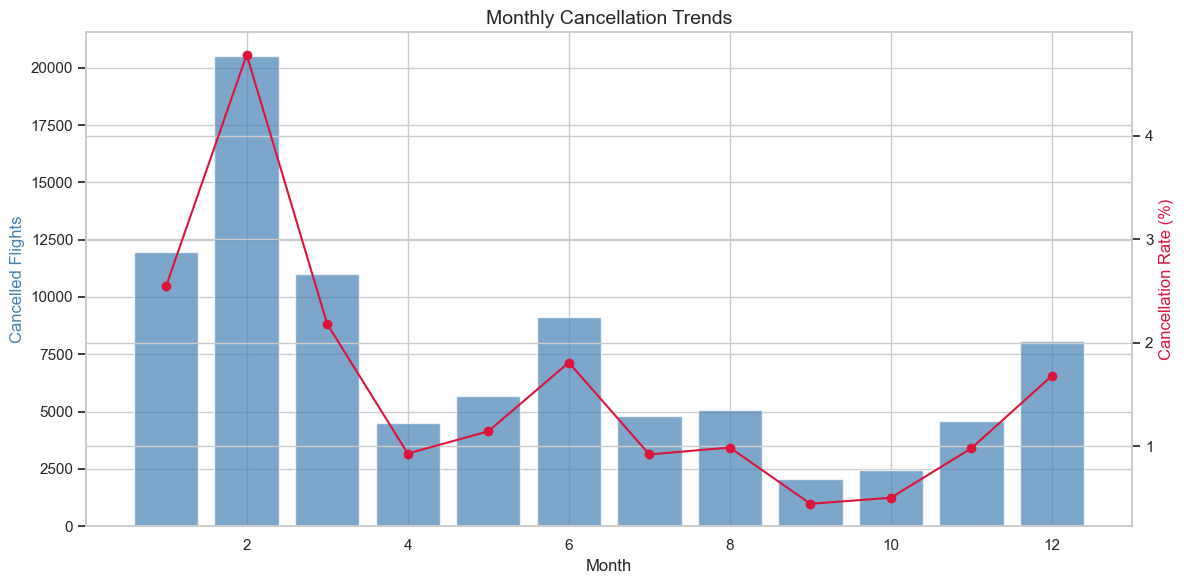

In [4]:
monthly_cancel = df.groupby('MONTH').agg(
    total_flights=('CANCELLED', 'count'),
    cancelled=('CANCELLED', 'sum')
).reset_index()
monthly_cancel['cancel_rate'] = monthly_cancel['cancelled'] / monthly_cancel['total_flights'] * 100

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(monthly_cancel['MONTH'], monthly_cancel['cancelled'], color='steelblue', alpha=0.7, label='Cancelled Flights')
ax1.set_xlabel("Month")
ax1.set_ylabel("Cancelled Flights", color='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly_cancel['MONTH'], monthly_cancel['cancel_rate'], color='crimson', marker='o', label='Cancellation Rate %')
ax2.set_ylabel("Cancellation Rate (%)", color='crimson')

plt.title("Monthly Cancellation Trends", fontsize=14)
fig.tight_layout()
plt.savefig("plot_3.png", dpi=150)
plt.show()

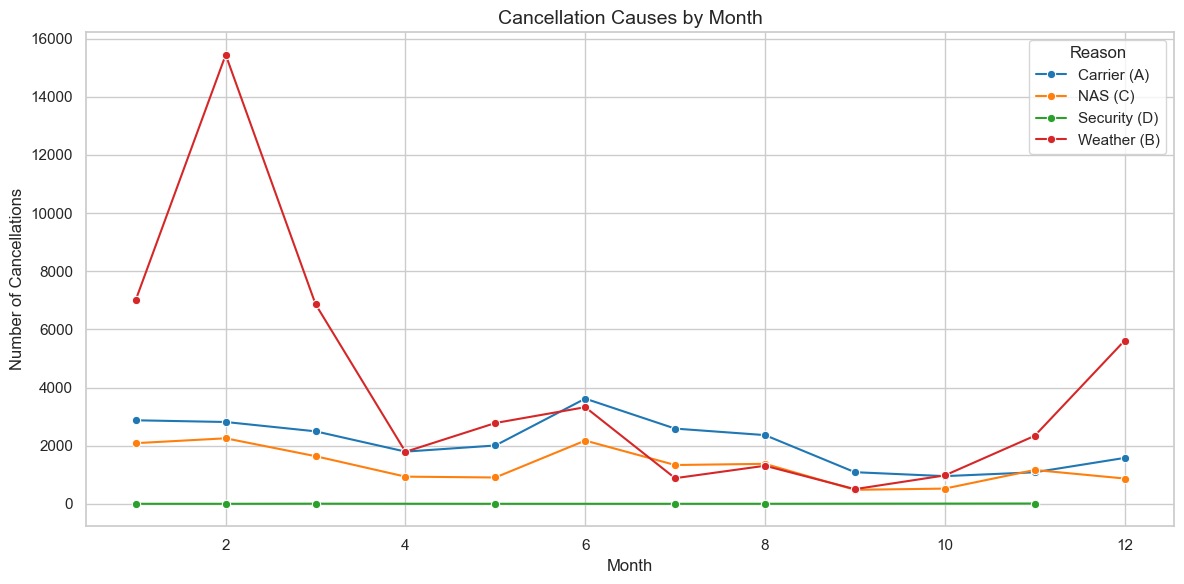

In [5]:
cancel_df = df[df['CANCELLED'] == 1].copy()
cancel_df['CANCELLATION_REASON'] = cancel_df['CANCELLATION_REASON'].replace({
    'A': 'Carrier (A)', 'B': 'Weather (B)',
    'C': 'NAS (C)', 'D': 'Security (D)'
})

cause_by_month = (
    cancel_df.groupby(['MONTH', 'CANCELLATION_REASON'])
    .size().reset_index(name='COUNT')
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=cause_by_month, x='MONTH', y='COUNT', 
             hue='CANCELLATION_REASON', marker='o', palette='tab10')
plt.title("Cancellation Causes by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Cancellations")
plt.legend(title="Reason")
plt.tight_layout()
plt.savefig("plot_4.png", dpi=150)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_24484\2687624143.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holiday_perf, x='IS_HOLIDAY', y='on_time_rate', ax=axes[0], palette='Set2')
C:\Users\Asus\AppData\Local\Temp\ipykernel_24484\2687624143.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holiday_perf, x='IS_HOLIDAY', y='avg_delay', ax=axes[1], palette='Set1')


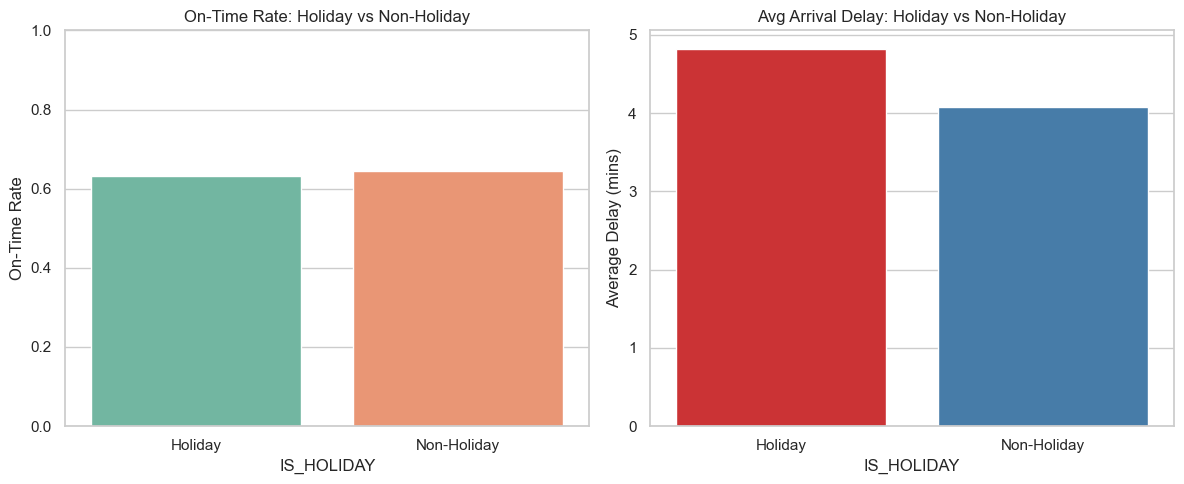

In [6]:
# Define major US holiday months (Nov=11, Dec=12, Jan=1, Jul=4)
holiday_months = [1, 7, 11, 12]
df['IS_HOLIDAY'] = df['MONTH'].isin(holiday_months).map({True: 'Holiday', False: 'Non-Holiday'})

holiday_perf = df.groupby('IS_HOLIDAY').agg(
    on_time_rate=('ON_TIME', 'mean'),
    avg_delay=('ARRIVAL_DELAY', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=holiday_perf, x='IS_HOLIDAY', y='on_time_rate', ax=axes[0], palette='Set2')
axes[0].set_title("On-Time Rate: Holiday vs Non-Holiday")
axes[0].set_ylabel("On-Time Rate")
axes[0].set_ylim(0, 1)

sns.barplot(data=holiday_perf, x='IS_HOLIDAY', y='avg_delay', ax=axes[1], palette='Set1')
axes[1].set_title("Avg Arrival Delay: Holiday vs Non-Holiday")
axes[1].set_ylabel("Average Delay (mins)")

plt.tight_layout()
plt.savefig("plot_5.png", dpi=150)
plt.show()

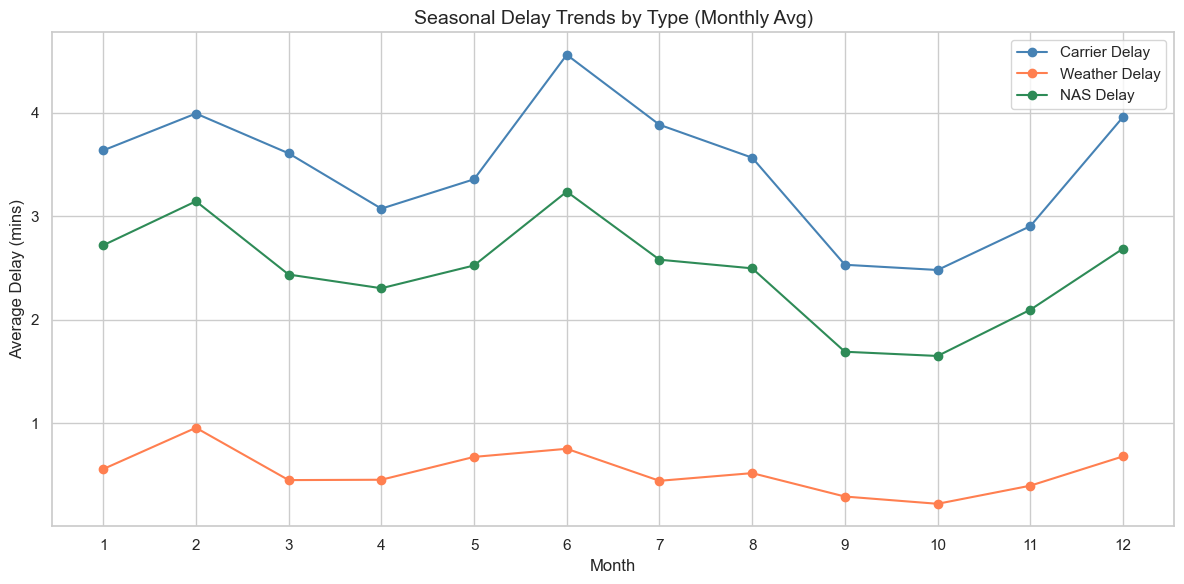

In [7]:
seasonal_delays = df.groupby('MONTH')[['AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY']].mean().reset_index()

plt.figure(figsize=(12, 6))
for col, label, color in zip(
    ['AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY'],
    ['Carrier Delay', 'Weather Delay', 'NAS Delay'],
    ['steelblue', 'coral', 'seagreen']
):
    plt.plot(seasonal_delays['MONTH'], seasonal_delays[col], marker='o', label=label, color=color)

plt.title("Seasonal Delay Trends by Type (Monthly Avg)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Delay (mins)")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.savefig("plot_6.png", dpi=150)
plt.show()

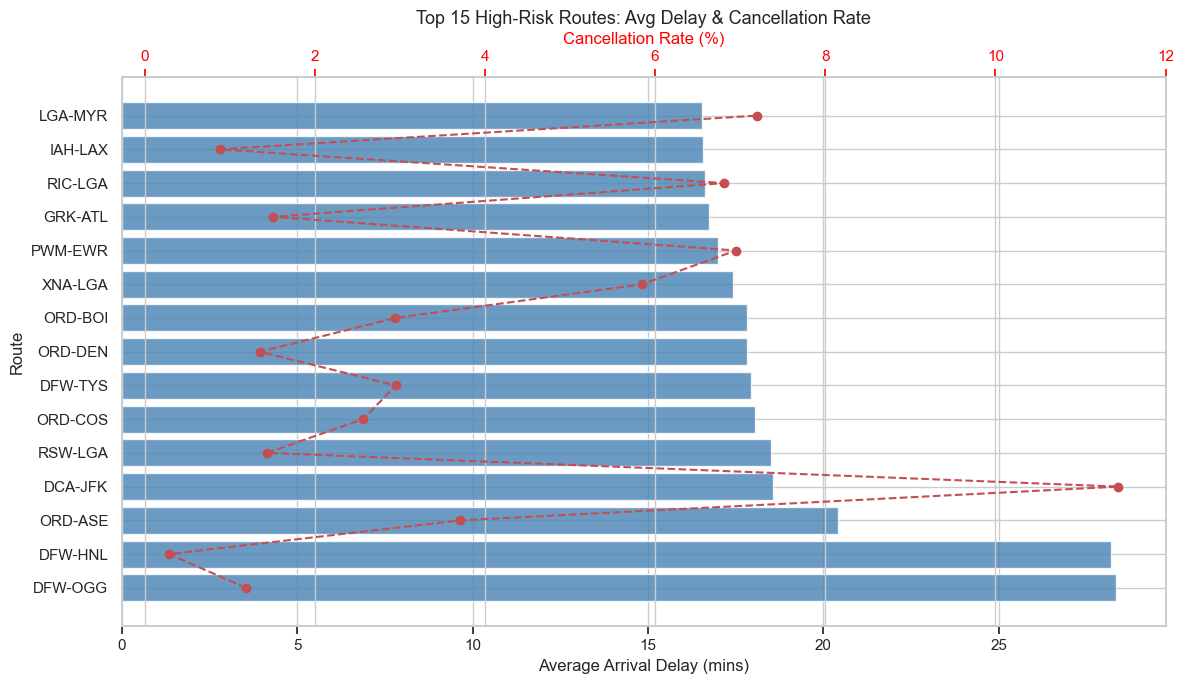

In [8]:
route_stats = df.groupby('ROUTE').agg(
    avg_delay=('ARRIVAL_DELAY', 'mean'),
    cancel_prob=('CANCELLED', 'mean'),
    flight_count=('CANCELLED', 'count')
).reset_index()

# Filter to routes with enough data
route_stats = route_stats[route_stats['flight_count'] >= 500]
top_risk = route_stats.nlargest(15, 'avg_delay')

fig, ax1 = plt.subplots(figsize=(12, 7))
bars = ax1.barh(top_risk['ROUTE'], top_risk['avg_delay'], color='steelblue', alpha=0.8)
ax1.set_xlabel("Average Arrival Delay (mins)")
ax1.set_ylabel("Route")

ax2 = ax1.twiny()
ax2.plot(top_risk['cancel_prob'] * 100, top_risk['ROUTE'], 
         'ro--', linewidth=1.5, markersize=6, label='Cancellation %')
ax2.set_xlabel("Cancellation Rate (%)", color='red')
ax2.tick_params(axis='x', colors='red')

plt.title("Top 15 High-Risk Routes: Avg Delay & Cancellation Rate", fontsize=13)
plt.tight_layout()
plt.savefig("plot_7.png", dpi=150)
plt.show()